# Experiment 01 - Distance to Linear Regime

Goal:
Estimate how far a dataset is from ideal linear coherence using spectral structure. The goal is to explore how much of a dataset's total variance is not explained by the first k prinicipal componenets.

Datasets:
Synthetically generated datasets representing known geometric outcomes - Perfect line, circle, Gaussian noise.
Data will be mean centred and standardized, in order for the probe to be scale invariant.




In [1]:
# Dependencies

import numpy as np
from numpy.typing import NDArray
import pandas as pd

In [2]:
# Generate synthetic datasets (Perfect Line, Perfect Line with Noise, 2D plane, Circle, Gaussian Noise)

# Set seed for reproducibility
np.random.seed(42)

# Generate perfect line

def generate_line_df(n: int, d: int) -> NDArray[np.float64]:

    """
    Takes n samples, d features and generates a perfectly linear array with rank 1.

    :param n: First integer
    :param d: Second integer
    :return line_df: d dimensional array with n rows
    """

    v = np.random.uniform(1, 50, size=d)

    t = np.random.uniform(-1, 1, size=n)

    line_df = np.outer(t, v)

    return line_df

def generate_gaussian_noise_df(n: int, d: int) -> NDArray[np.float64]:

    
    """
    Takes n samples, d features and generates a noisy dataset of distribution (0,1)

    :param n: First integer
    :param d: Second integer
    :return noise_df: d dimensional array with n rows
    """

    noise_df = np.random.normal(0, 1 , size=(n, d))

    return noise_df

def generate_plane_df(n: int, d: int) -> NDArray[np.float64]:

    
    """
    Takes n samples, d features and generates a dataset with 2 prinicipal directions (plane) in d-space

    :param n: First integer
    :param d: Second integer
    :return plane_df: d dimensional array with n rows
    """

    # Generate latent scalars
    ai = np.random.uniform(-1, 1, size=n)
    bi = np.random.uniform(-1, 1, size=n)

    # Generate vectors
    v1 = np.random.uniform(-1, 1, size=d)
    v2 = np.random.uniform(-1, 1, size=d)

    aiv = np.outer(ai, v1)
    biv = np.outer(bi, v2)

    plane_df = aiv + biv

    return plane_df

def generate_circle_df(n: int, d: int) -> NDArray[np.float64]:

    """
    Takes n samples, d features and generates a circular manifold embedded in d-dimensional space

    :param n: First integer
    :param d: Second integer
    :return circle_df: d dimensional array with n rows
    """
        
    a = np.random.uniform(0, 2*np.pi, size=n)

    v1 = np.random.uniform(-1, 1, size=d)
    v2 = np.random.uniform(-1, 1, size=d)

    av1 = np.outer(np.cos(a), v1)
    av2 = np.outer(np.sin(a), v2)

    circle_df = av1 + av2
    return circle_df
    


def add_noise(scalar: float, df: NDArray[np.float64]) -> NDArray[np.float64]:

    """
    Takes n samples, d features, df

    :param scalar: Scalar for noise control, percentage
    :param df: array with n samples and d features
    :return df_with_noise: n*d array with added noise
    
    """

    n, d = df.shape

    df_std = np.std(df, axis=0, ddof=0)

    Z = np.random.normal(0, 1 , size=(n, d))

    E = scalar * df_std * Z

    df_with_noise = E + df

    return df_with_noise





In [3]:

# Set n sample and d features
n = 1000
d = 50

# Generate datasets
line_df = generate_line_df(n, d)
line_with_noise = add_noise(scalar=0.01, df=line_df)
plane_df = generate_plane_df(n, d)
circle_df = generate_circle_df(n, d)
noise_df = generate_gaussian_noise_df(n, d)

# Rank expectations
print(f"Perfect line expects rank 1, got {np.linalg.matrix_rank(line_df)}")
print(f"Plane expects rank 2, got {np.linalg.matrix_rank(plane_df)}")
print(f"Circle expects rank 2, got {np.linalg.matrix_rank(circle_df)}")
print(f"Line with noise expects rank ~{d}, got {np.linalg.matrix_rank(line_with_noise)}")
print(f"Gaussian noise expects rank ~{d}, got {np.linalg.matrix_rank(noise_df)}")

Perfect line expects rank 1, got 1
Plane expects rank 2, got 2
Circle expects rank 2, got 2
Line with noise expects rank ~50, got 50
Gaussian noise expects rank ~50, got 50


The above displays that rank is a binary property and becomes unstable even under small pertubations, whereas spectral residual measures preserve graded information about structural coherence.

In [4]:
# Functionality for delta_lin. Data is mean-centered and standardized, singular values are squared for energy.

def delta_lin(X: NDArray[np.float64], k: int) -> float:

    """ 
    delta_lin takes an n*d array, mean centers and standardizing it so it is scale invariant, performs SVD, and returns the spectral residual left after rank k.

    :param X: array
    :param k: int
    :return delta_lin_k: float

    """
    # Mean centre and standardize
    X_centre = (X - np.mean(X, axis=0))
    X_sigma = np.std(X, axis=0, ddof=0)

    # Replace std of 0 with 1
    X_sigma[X_sigma == 0] = 1

    X_scaled = X_centre / X_sigma

    # Compute SVD
    U, S, vt = np.linalg.svd(X_scaled, full_matrices=False)

    if k < 1:
        raise ValueError(f"k must be 1 or larger")

    # Square to get variance
    S_squared = S*S

    total_energy = sum(S_squared)
    first_k_energy = sum(S_squared[:k])

    # Return
    delta_lin_k = 1 - (first_k_energy / total_energy)

    return delta_lin_k

def generate_delta_lin_curve(df: NDArray[np.float64]) -> list:

    """ 
    Generates delta curve for 1 : k

    :param df: array
    :return delta_values: list

    """
    delta_values = []

    n, d = df.shape

    for i in range(1, d+1):
        delta_lin_k = delta_lin(df, i)
        delta_values.append(delta_lin_k)

    return delta_values
        


In [5]:
delta_line = generate_delta_lin_curve(line_df)
delta_plane = generate_delta_lin_curve(plane_df)
delta_circle = generate_delta_lin_curve(circle_df)
delta_noise = generate_delta_lin_curve(noise_df)
delta_line_with_noise = generate_delta_lin_curve(line_with_noise)

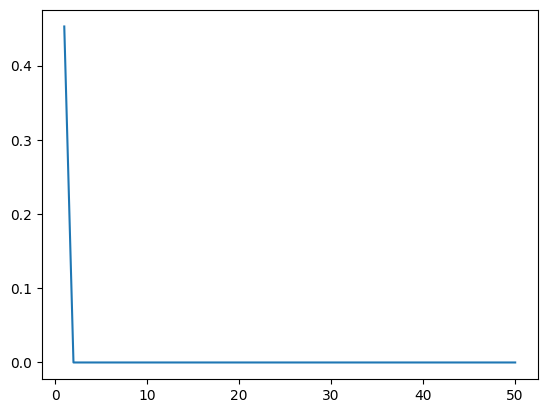

In [9]:
import matplotlib.pyplot as plt

k_values = range(1, d+1)
plt.plot(k_values, delta_plane)
plt.show()
